# 03. Immune Microenvironment Analysis

## Objective

Characterise the immune-cell compartment of the CID4465 TNBC tumour and investigate transcriptional heterogeneity among T cells, myeloid cells, B-lineage cells, and plasmablasts.

## Main goals

1. Extract immune-cell populations from the processed single-cell dataset.
2. Recompute dimensionality reduction within the immune compartment.
3. Identify immune-specific subclusters.
4. Discover marker genes for immune subpopulations.
5. Evaluate T-cell activation/exhaustion markers.
6. Evaluate myeloid antigen-presentation and inflammatory programmes.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

print("Core libraries loaded successfully.")

Core libraries loaded successfully.


In [2]:
project_dir = Path.cwd().parent

data_dir = project_dir / "data"
processed_dir = data_dir / "processed"
figures_dir = project_dir / "figures"
results_dir = project_dir / "results"

processed_file = processed_dir / "CID4465_processed.h5ad"

adata = sc.read_h5ad(processed_file)

print(adata)

AnnData object with n_obs × n_vars = 1534 × 13514
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'predicted_celltype'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p'
    obsm: 'X_umap'
    layers: 'counts', None (.X)


In [3]:
immune_celltypes = [
    "Myeloid",
    "T-cells",
    "Plasmablasts",
    "B/Plasmablast"
]

adata_immune = adata[
    adata.obs["predicted_celltype"].isin(
        immune_celltypes
    )
].copy()

print("Immune AnnData:")
print(adata_immune)

print("\nImmune cell-type distribution:")
print(
    adata_immune.obs["predicted_celltype"]
    .value_counts()
)

Immune AnnData:
AnnData object with n_obs × n_vars = 431 × 13514
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'predicted_celltype'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p'
    obsm: 'X_umap'
    layers: 'counts', None (.X)

Immune cell-type distribution:
predicted_celltype
Myeloid          176
T-cells          116
Plasmablasts      82
B/Plasmablast     57
Name: count, dtype: int64


In [4]:
print("=== IMMUNE COMPARTMENT QC ===")

print("Immune cells:", adata_immune.n_obs)
print("Genes:", adata_immune.n_vars)

print("\nGenes detected per cell:")
print(
    adata_immune.obs["n_genes_by_counts"]
    .describe()
)

print("\nMitochondrial percentage:")
print(
    adata_immune.obs["pct_counts_mt"]
    .describe()
)

=== IMMUNE COMPARTMENT QC ===
Immune cells: 431
Genes: 13514

Genes detected per cell:
count     431.000000
mean      450.250580
std       224.493274
min       202.000000
25%       291.500000
50%       393.000000
75%       549.500000
max      1991.000000
Name: n_genes_by_counts, dtype: float64

Mitochondrial percentage:
count    431.000000
mean       2.531776
std        1.931538
min        0.186916
25%        0.784839
50%        2.237136
75%        3.787687
max        9.572072
Name: pct_counts_mt, dtype: float64


In [5]:
# Re-identify highly variable genes within immune cells

sc.pp.highly_variable_genes(
    adata_immune,
    n_top_genes=1500,
    flavor="seurat"
)

print(
    "Immune highly variable genes:",
    adata_immune.var["highly_variable"].sum()
)

Immune highly variable genes: 1500


In [6]:
adata_immune_hvg = adata_immune[
    :,
    adata_immune.var["highly_variable"]
].copy()

print(adata_immune_hvg)

AnnData object with n_obs × n_vars = 431 × 1500
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'predicted_celltype'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p'
    obsm: 'X_umap'
    layers: 'counts', None (.X)


In [7]:
sc.pp.scale(
    adata_immune_hvg,
    max_value=10
)

sc.tl.pca(
    adata_immune_hvg,
    n_comps=30,
    svd_solver="arpack"
)

print(
    "Immune PCA shape:",
    adata_immune_hvg.obsm["X_pca"].shape
)

/opt/anaconda3/envs/cancer-informatics/lib/python3.12/functools.py:907: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Immune PCA shape: (431, 30)


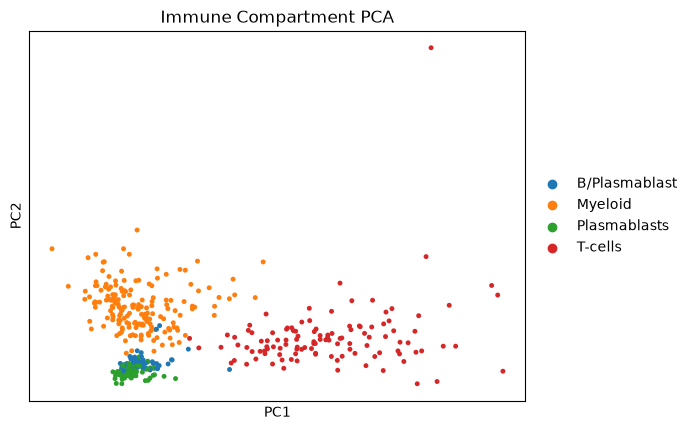

In [8]:
sc.pl.pca(
    adata_immune_hvg,
    color="predicted_celltype",
    size=50,
    title="Immune Compartment PCA"
)

In [9]:
sc.pp.neighbors(
    adata_immune_hvg,
    n_neighbors=15,
    n_pcs=15
)

print("Immune neighbour graph constructed.")

/opt/anaconda3/envs/cancer-informatics/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Immune neighbour graph constructed.


In [10]:
sc.tl.umap(
    adata_immune_hvg,
    random_state=42
)

print("Immune UMAP complete.")

Immune UMAP complete.


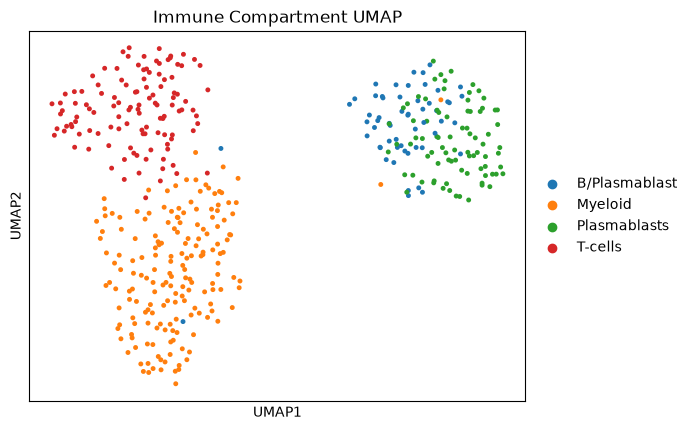

In [11]:
sc.pl.umap(
    adata_immune_hvg,
    color="predicted_celltype",
    size=50,
    title="Immune Compartment UMAP"
)

In [12]:
sc.tl.leiden(
    adata_immune_hvg,
    resolution=0.4,
    key_added="immune_leiden",
    flavor="igraph",
    n_iterations=2,
    directed=False,
    random_state=42
)

print("Immune Leiden clustering complete.")

print(
    adata_immune_hvg.obs["immune_leiden"]
    .value_counts()
    .sort_index()
)

Immune Leiden clustering complete.
immune_leiden
0    139
1    117
2    175
Name: count, dtype: int64


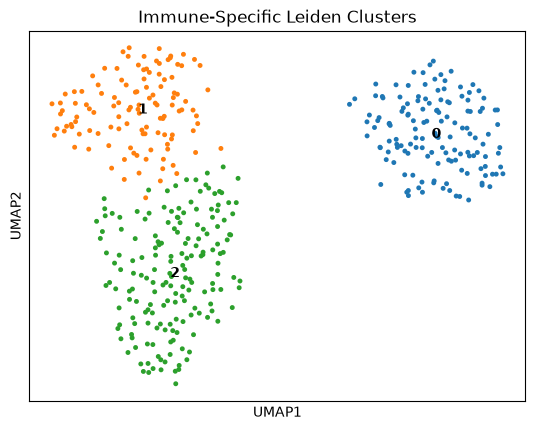

In [13]:
sc.pl.umap(
    adata_immune_hvg,
    color="immune_leiden",
    legend_loc="on data",
    size=50,
    title="Immune-Specific Leiden Clusters"
)

In [14]:
immune_cluster_table = pd.crosstab(
    adata_immune_hvg.obs["immune_leiden"],
    adata_immune_hvg.obs["predicted_celltype"]
)

display(immune_cluster_table)

predicted_celltype,B/Plasmablast,Myeloid,Plasmablasts,T-cells
immune_leiden,,,,
0,55,2,82,0
1,1,1,0,115
2,1,173,0,1


In [15]:
# Transfer immune clustering results back to full-gene immune object

adata_immune.obs["immune_leiden"] = (
    adata_immune_hvg.obs["immune_leiden"].copy()
)

adata_immune.obsm["X_umap"] = (
    adata_immune_hvg.obsm["X_umap"].copy()
)

print("Immune cluster labels transferred.")

Immune cluster labels transferred.


In [16]:
# Identify marker genes for immune Leiden clusters

sc.tl.rank_genes_groups(
    adata_immune,
    groupby="immune_leiden",
    method="wilcoxon",
    key_added="immune_markers"
)

immune_marker_df = sc.get.rank_genes_groups_df(
    adata_immune,
    group=None,
    key="immune_markers"
)

print("Immune marker analysis complete.")
print("Marker result shape:", immune_marker_df.shape)

Immune marker analysis complete.
Marker result shape: (40542, 6)


In [17]:
for cluster in sorted(
    adata_immune.obs["immune_leiden"].unique(),
    key=int
):
    top_genes = (
        immune_marker_df[
            immune_marker_df["group"] == cluster
        ]
        .head(15)["names"]
        .tolist()
    )

    print(
        f"Cluster {cluster}:",
        ", ".join(top_genes)
    )

Cluster 0: JCHAIN, SSR4, DERL3, IGHG3, IGHG1, IGKC, MZB1, XBP1, IGLC3, IGHGP, FKBP11, IGLC2, IGHG4, IGHA1, IGHG2
Cluster 1: B2M, TRAC, PFN1, IL32, PTMA, CD52, CD3D, MALAT1, H3F3B, TMSB4X, UBB, CD2, TRBC2, LTB, TMA7
Cluster 2: FTL, CD74, HLA-DRA, HLA-DRB1, FTH1, HLA-DRB5, LYZ, NPC2, FCER1G, HLA-DPB1, AIF1, CAPG, HLA-DQB1, CST3, MT-CO1


In [18]:
# Extract T-cell compartment

adata_t = adata_immune[
    adata_immune.obs["immune_leiden"] == "1"
].copy()

print("T-cell AnnData:")
print(adata_t)

print("\nT-cell count:", adata_t.n_obs)

T-cell AnnData:
AnnData object with n_obs × n_vars = 117 × 13514
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'predicted_celltype', 'immune_leiden'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p', 'immune_markers'
    obsm: 'X_umap'
    layers: 'counts', None (.X)

T-cell count: 117


In [19]:
# T-cell-specific highly variable genes

sc.pp.highly_variable_genes(
    adata_t,
    n_top_genes=800,
    flavor="seurat"
)

adata_t_hvg = adata_t[
    :,
    adata_t.var["highly_variable"]
].copy()

print(adata_t_hvg)

AnnData object with n_obs × n_vars = 117 × 815
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'predicted_celltype', 'immune_leiden'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p', 'immune_markers'
    obsm: 'X_umap'
    layers: 'counts', None (.X)


In [20]:
sc.pp.scale(
    adata_t_hvg,
    max_value=10
)

sc.tl.pca(
    adata_t_hvg,
    n_comps=20,
    svd_solver="arpack"
)

sc.pp.neighbors(
    adata_t_hvg,
    n_neighbors=10,
    n_pcs=10
)

sc.tl.umap(
    adata_t_hvg,
    random_state=42
)

print("T-cell dimensionality reduction complete.")

T-cell dimensionality reduction complete.


/opt/anaconda3/envs/cancer-informatics/lib/python3.12/functools.py:907: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [21]:
tcell_markers = [
    "CD4",
    "CD8A",
    "CD8B",
    "NKG7",
    "CCL5",
    "GZMB",
    "PRF1",
    "PDCD1",
    "CTLA4",
    "LAG3",
    "TIGIT"
]

available_t_markers = [
    gene for gene in tcell_markers
    if gene in adata_t.var_names
]

print("Available T-cell markers:")
print(available_t_markers)

Available T-cell markers:
['CD4', 'CD8A', 'CD8B', 'NKG7', 'CCL5', 'GZMB', 'PRF1', 'PDCD1', 'CTLA4', 'LAG3', 'TIGIT']


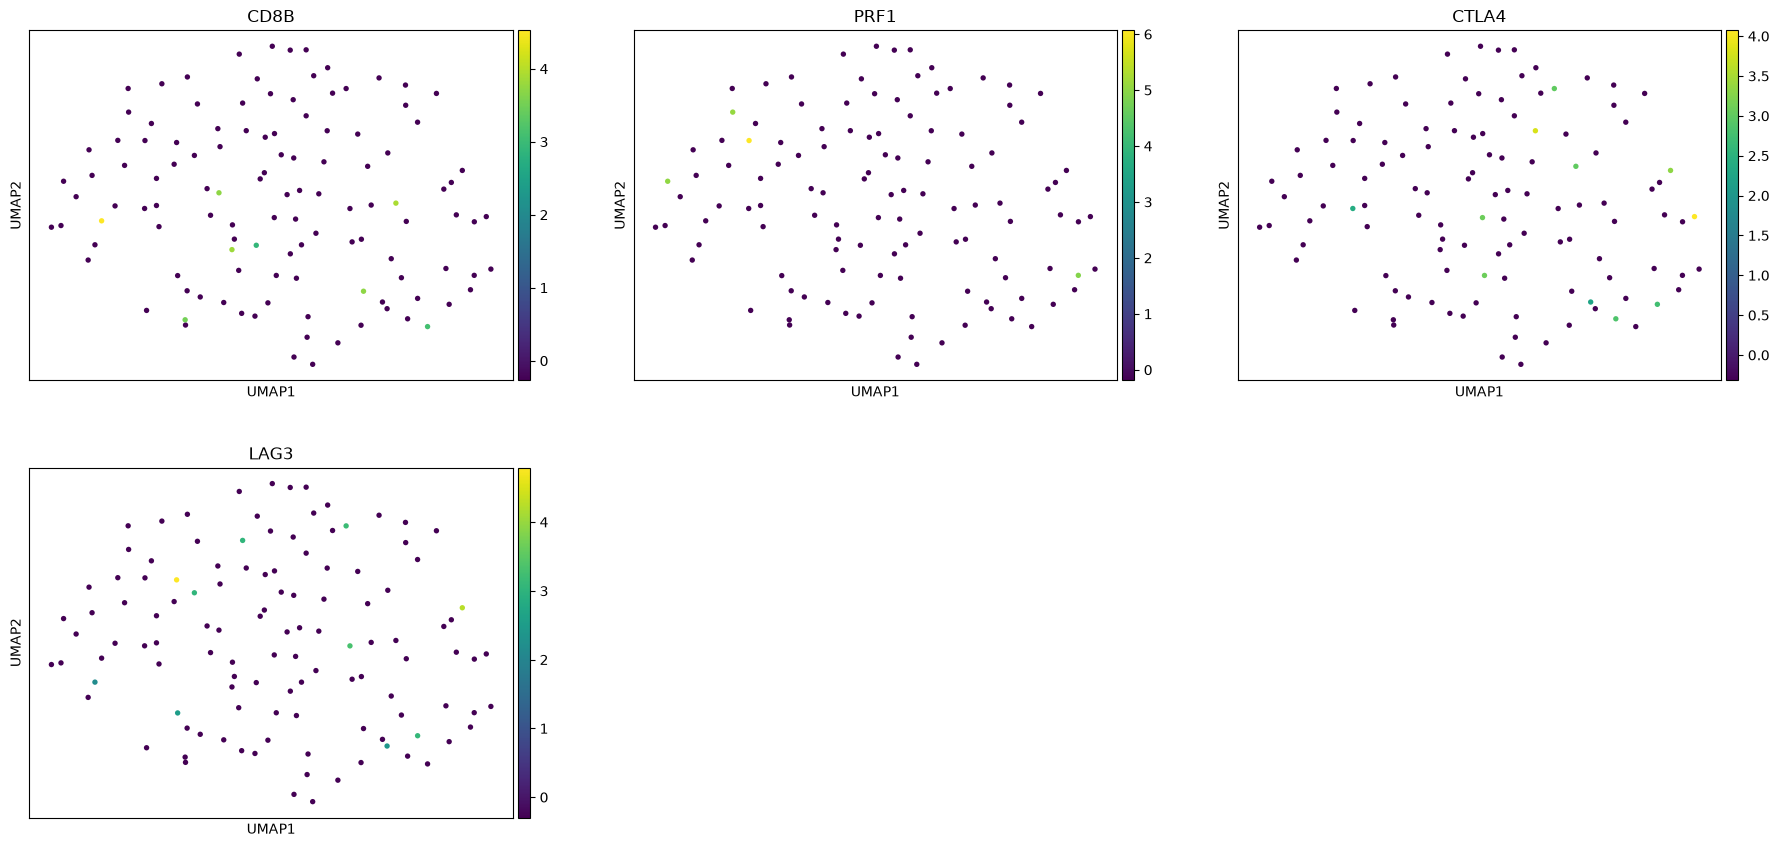

In [22]:
sc.pl.umap(
    adata_t_hvg,
    color=[
        gene for gene in available_t_markers
        if gene in adata_t_hvg.var_names
    ],
    ncols=3,
    size=60
)

In [23]:
# Define T-cell gene programs

cytotoxic_genes = [
    gene for gene in ["NKG7", "CCL5", "GZMB", "PRF1"]
    if gene in adata_t.var_names
]

exhaustion_genes = [
    gene for gene in ["PDCD1", "CTLA4", "LAG3", "TIGIT"]
    if gene in adata_t.var_names
]

cd8_genes = [
    gene for gene in ["CD8A", "CD8B"]
    if gene in adata_t.var_names
]

In [24]:
sc.tl.score_genes(
    adata_t,
    gene_list=cytotoxic_genes,
    score_name="cytotoxic_score",
    random_state=42
)

sc.tl.score_genes(
    adata_t,
    gene_list=exhaustion_genes,
    score_name="exhaustion_score",
    random_state=42
)

sc.tl.score_genes(
    adata_t,
    gene_list=cd8_genes,
    score_name="cd8_score",
    random_state=42
)

print(
    adata_t.obs[
        [
            "cytotoxic_score",
            "exhaustion_score",
            "cd8_score"
        ]
    ].describe()
)

       cytotoxic_score  exhaustion_score   cd8_score
count       117.000000        117.000000  117.000000
mean          0.303658          0.028941   -0.012557
std           0.936220          0.459630    0.532699
min          -0.894711         -0.379343   -0.484021
25%          -0.426387         -0.206097   -0.234221
50%          -0.224191         -0.145542   -0.167583
75%           0.945867         -0.068933   -0.109082
max           2.747458          2.274837    1.803803


In [25]:
for col in [
    "cytotoxic_score",
    "exhaustion_score",
    "cd8_score"
]:
    adata_t_hvg.obs[col] = adata_t.obs[col].copy()

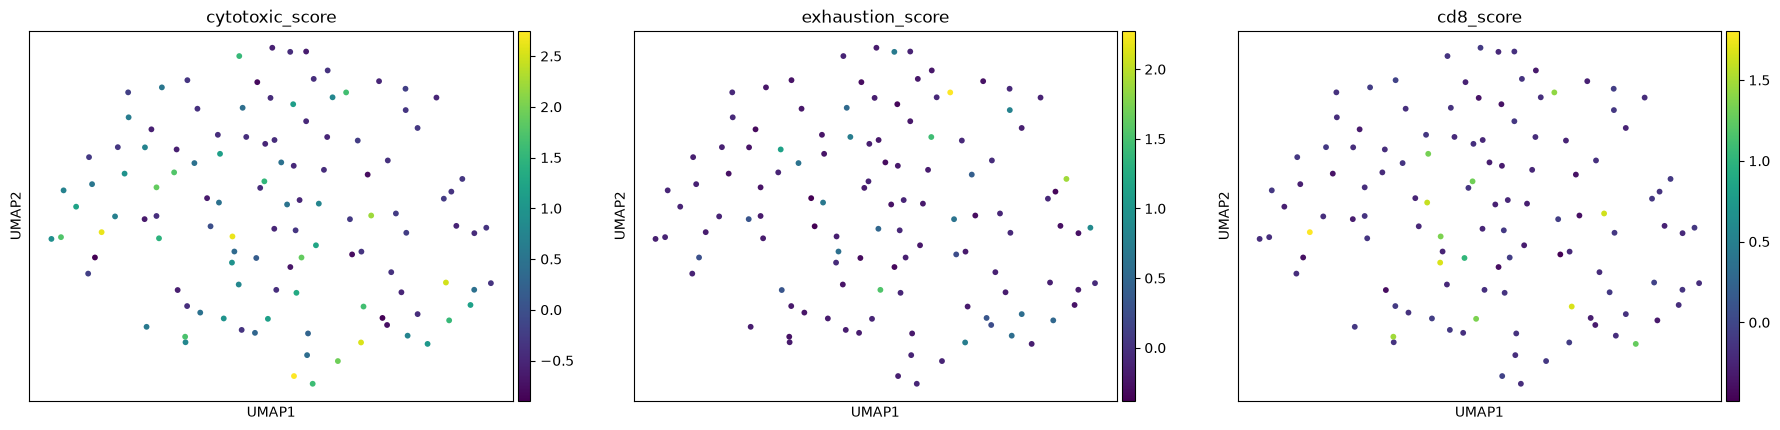

In [26]:
sc.pl.umap(
    adata_t_hvg,
    color=[
        "cytotoxic_score",
        "exhaustion_score",
        "cd8_score"
    ],
    ncols=3,
    size=70,
    cmap="viridis"
)

In [27]:
sc.tl.leiden(
    adata_t_hvg,
    resolution=0.25,
    key_added="tcell_leiden",
    flavor="igraph",
    n_iterations=2,
    directed=False,
    random_state=42
)

print("T-cell Leiden clusters:")
print(
    adata_t_hvg.obs["tcell_leiden"]
    .value_counts()
    .sort_index()
)

T-cell Leiden clusters:
tcell_leiden
0    117
Name: count, dtype: int64


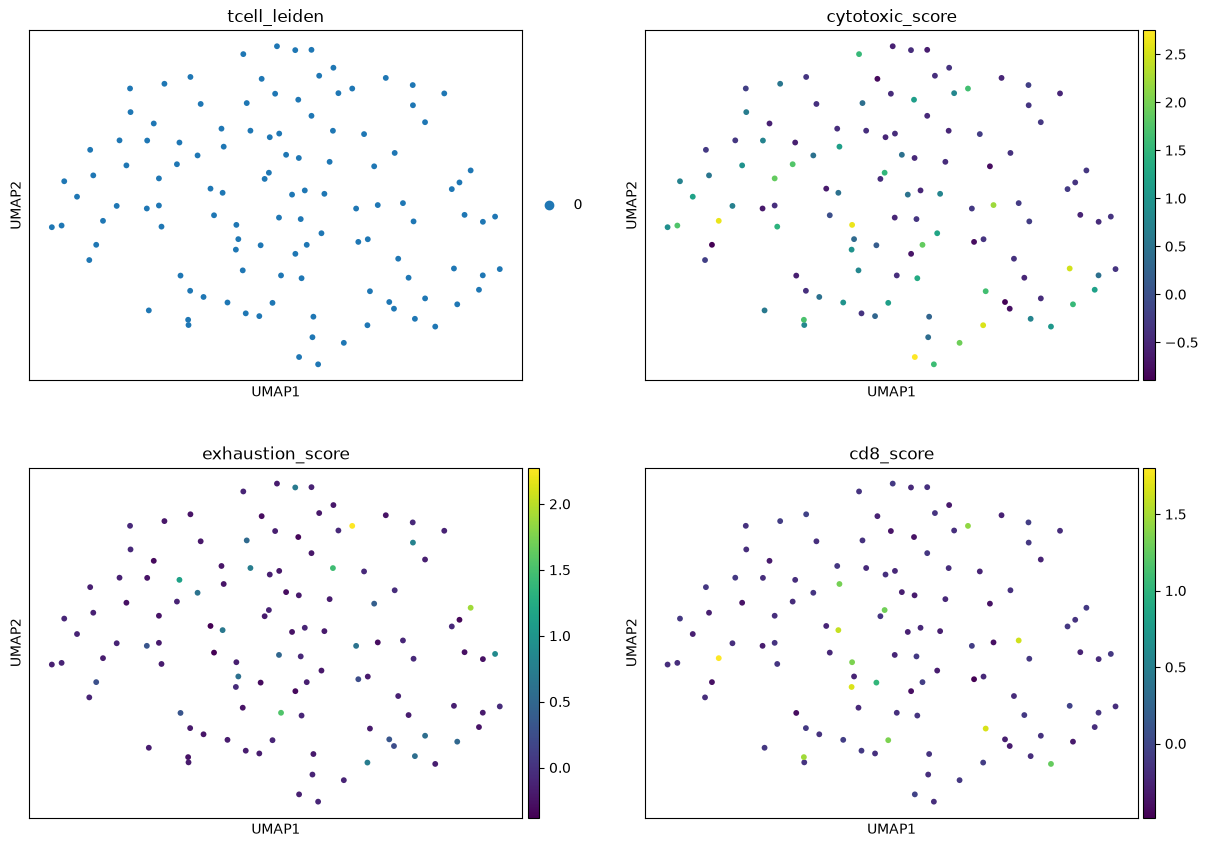

In [28]:
sc.pl.umap(
    adata_t_hvg,
    color=[
        "tcell_leiden",
        "cytotoxic_score",
        "exhaustion_score",
        "cd8_score"
    ],
    ncols=2,
    size=70
)

In [29]:
tcell_score_summary = (
    adata_t_hvg.obs
    .groupby("tcell_leiden")[
        [
            "cytotoxic_score",
            "exhaustion_score",
            "cd8_score"
        ]
    ]
    .mean()
)

display(tcell_score_summary.round(3))

/var/folders/gr/dczgzvyn4w1c3nb_7lb1vr7m0000gn/T/ipykernel_8586/1611106665.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("tcell_leiden")[


,cytotoxic_score,exhaustion_score,cd8_score
tcell_leiden,,,
0,0.304,0.029,-0.013


In [30]:
# Extract myeloid compartment

adata_myeloid = adata_immune[
    adata_immune.obs["immune_leiden"] == "2"
].copy()

print("Myeloid AnnData:")
print(adata_myeloid)

print("\nMyeloid cell count:", adata_myeloid.n_obs)

Myeloid AnnData:
AnnData object with n_obs × n_vars = 175 × 13514
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'predicted_celltype', 'immune_leiden'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p', 'immune_markers'
    obsm: 'X_umap'
    layers: 'counts', None (.X)

Myeloid cell count: 175


In [31]:
# Myeloid-specific highly variable genes

sc.pp.highly_variable_genes(
    adata_myeloid,
    n_top_genes=800,
    flavor="seurat"
)

adata_myeloid_hvg = adata_myeloid[
    :,
    adata_myeloid.var["highly_variable"]
].copy()

print(adata_myeloid_hvg)

AnnData object with n_obs × n_vars = 175 × 800
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'predicted_celltype', 'immune_leiden'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p', 'immune_markers'
    obsm: 'X_umap'
    layers: 'counts', None (.X)


In [32]:
sc.pp.scale(
    adata_myeloid_hvg,
    max_value=10
)

sc.tl.pca(
    adata_myeloid_hvg,
    n_comps=20,
    svd_solver="arpack"
)

sc.pp.neighbors(
    adata_myeloid_hvg,
    n_neighbors=10,
    n_pcs=10
)

sc.tl.umap(
    adata_myeloid_hvg,
    random_state=42
)

print("Myeloid dimensionality reduction complete.")

/opt/anaconda3/envs/cancer-informatics/lib/python3.12/functools.py:907: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Myeloid dimensionality reduction complete.


In [33]:
myeloid_markers = [
    "LYZ",
    "FCER1G",
    "AIF1",
    "CD68",
    "C1QA",
    "C1QB",
    "C1QC",
    "APOE",
    "HLA-DRA",
    "CD74",
    "S100A8",
    "S100A9"
]

available_myeloid_markers = [
    gene for gene in myeloid_markers
    if gene in adata_myeloid.var_names
]

print("Available myeloid markers:")
print(available_myeloid_markers)

Available myeloid markers:
['LYZ', 'FCER1G', 'AIF1', 'CD68', 'C1QA', 'C1QB', 'C1QC', 'APOE', 'HLA-DRA', 'CD74', 'S100A8', 'S100A9']


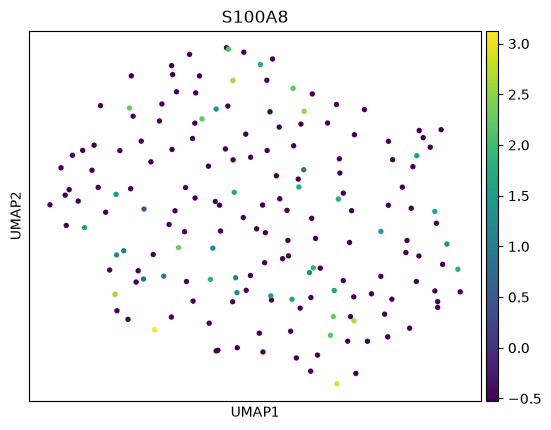

In [34]:
sc.pl.umap(
    adata_myeloid_hvg,
    color=[
        gene for gene in available_myeloid_markers
        if gene in adata_myeloid_hvg.var_names
    ],
    ncols=3,
    size=60
)

In [35]:
# Define myeloid transcriptional programmes

macrophage_genes = [
    gene for gene in [
        "C1QA", "C1QB", "C1QC",
        "APOE", "CD68"
    ]
    if gene in adata_myeloid.var_names
]

antigen_presentation_genes = [
    gene for gene in [
        "HLA-DRA", "CD74"
    ]
    if gene in adata_myeloid.var_names
]

inflammatory_genes = [
    gene for gene in [
        "S100A8", "S100A9"
    ]
    if gene in adata_myeloid.var_names
]

print("Macrophage genes:", macrophage_genes)
print("Antigen-presentation genes:", antigen_presentation_genes)
print("Inflammatory genes:", inflammatory_genes)

Macrophage genes: ['C1QA', 'C1QB', 'C1QC', 'APOE', 'CD68']
Antigen-presentation genes: ['HLA-DRA', 'CD74']
Inflammatory genes: ['S100A8', 'S100A9']


In [36]:
sc.tl.score_genes(
    adata_myeloid,
    gene_list=macrophage_genes,
    score_name="macrophage_score",
    random_state=42
)

sc.tl.score_genes(
    adata_myeloid,
    gene_list=antigen_presentation_genes,
    score_name="antigen_presentation_score",
    random_state=42
)

sc.tl.score_genes(
    adata_myeloid,
    gene_list=inflammatory_genes,
    score_name="inflammatory_score",
    random_state=42
)

print(
    adata_myeloid.obs[
        [
            "macrophage_score",
            "antigen_presentation_score",
            "inflammatory_score"
        ]
    ].describe()
)

       macrophage_score  antigen_presentation_score  inflammatory_score
count        175.000000                  175.000000          175.000000
mean           0.352510                    2.811308           -0.293937
std            1.199160                    0.935245            0.657851
min           -1.739107                   -1.110623           -1.060979
25%           -0.801066                    2.358387           -0.737903
50%            0.288782                    2.982085           -0.559653
75%            1.296342                    3.443929            0.161250
max            2.872883                    4.770924            1.805299


In [37]:
for col in [
    "macrophage_score",
    "antigen_presentation_score",
    "inflammatory_score"
]:
    adata_myeloid_hvg.obs[col] = (
        adata_myeloid.obs[col].copy()
    )

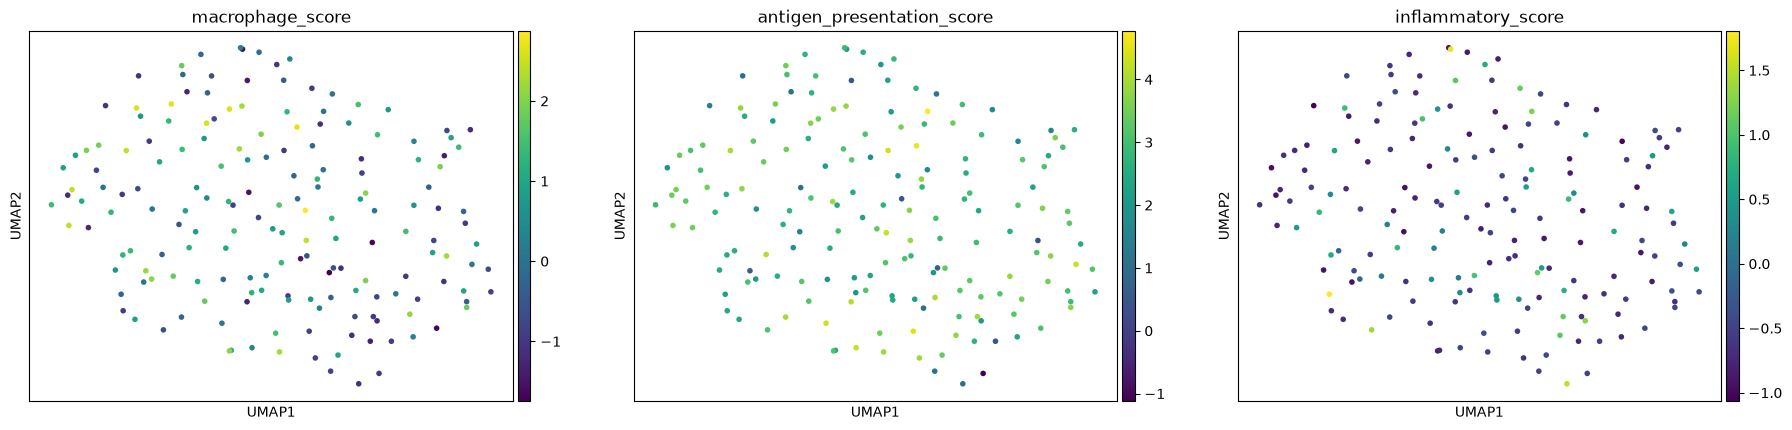

In [38]:
sc.pl.umap(
    adata_myeloid_hvg,
    color=[
        "macrophage_score",
        "antigen_presentation_score",
        "inflammatory_score"
    ],
    ncols=3,
    size=65,
    cmap="viridis"
)

In [39]:
sc.tl.leiden(
    adata_myeloid_hvg,
    resolution=0.25,
    key_added="myeloid_leiden",
    flavor="igraph",
    n_iterations=2,
    directed=False,
    random_state=42
)

print("Myeloid Leiden clusters:")
print(
    adata_myeloid_hvg.obs["myeloid_leiden"]
    .value_counts()
    .sort_index()
)

Myeloid Leiden clusters:
myeloid_leiden
0    175
Name: count, dtype: int64


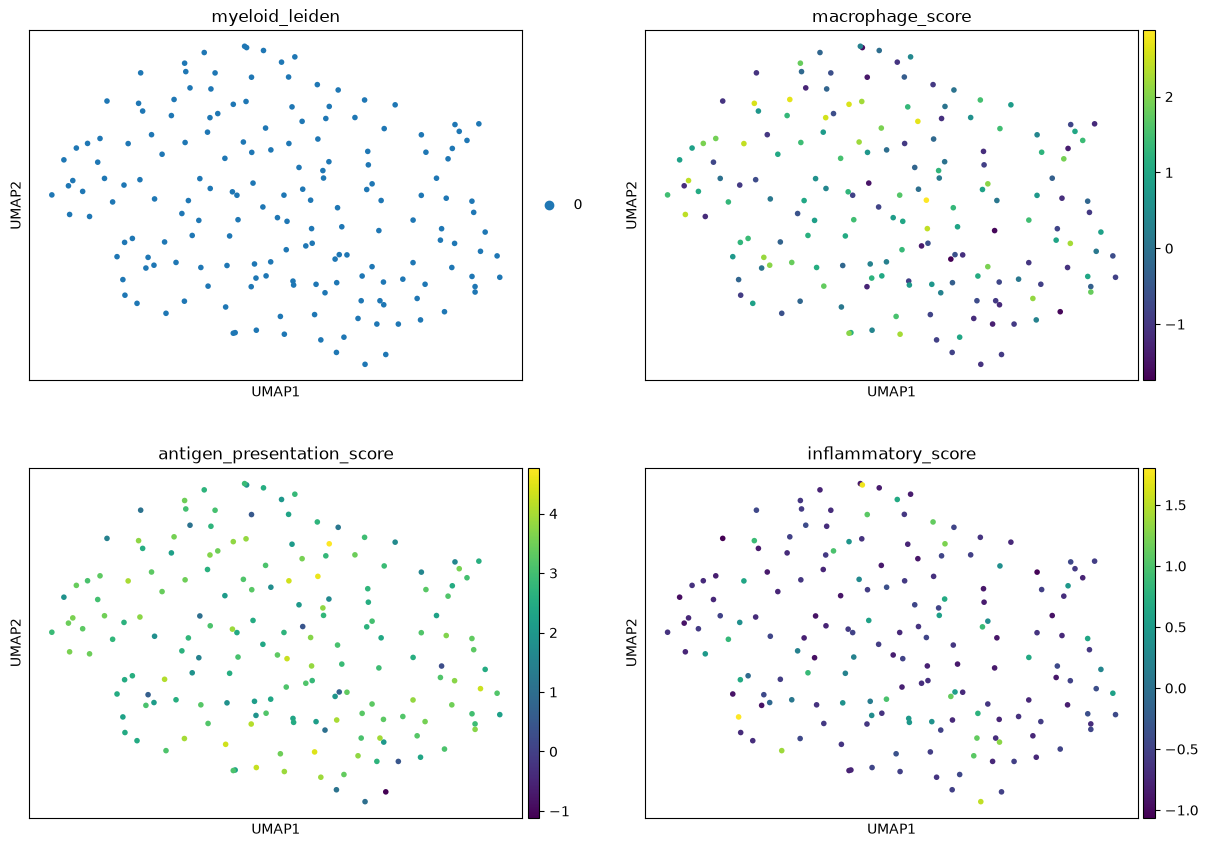

In [40]:
sc.pl.umap(
    adata_myeloid_hvg,
    color=[
        "myeloid_leiden",
        "macrophage_score",
        "antigen_presentation_score",
        "inflammatory_score"
    ],
    ncols=2,
    size=65
)

In [41]:
myeloid_score_summary = (
    adata_myeloid_hvg.obs
    .groupby(
        "myeloid_leiden",
        observed=True
    )[
        [
            "macrophage_score",
            "antigen_presentation_score",
            "inflammatory_score"
        ]
    ]
    .mean()
)

display(myeloid_score_summary.round(3))

,macrophage_score,antigen_presentation_score,inflammatory_score
myeloid_leiden,,,
0,0.353,2.811,-0.294


In [42]:
# Save T-cell programme summary

tcell_summary_path = (
    results_dir / "03_tcell_programme_summary.csv"
)

tcell_score_summary.to_csv(tcell_summary_path)

print("Saved T-cell summary to:")
print(tcell_summary_path)

Saved T-cell summary to:
/Users/zeyuliu/Projects/Cancer-Informatics-Portfolio/02_BRCA_Single_Cell_TME/results/03_tcell_programme_summary.csv


In [43]:
# Save myeloid programme summary

myeloid_summary_path = (
    results_dir / "03_myeloid_programme_summary.csv"
)

myeloid_score_summary.to_csv(myeloid_summary_path)

print("Saved myeloid summary to:")
print(myeloid_summary_path)

Saved myeloid summary to:
/Users/zeyuliu/Projects/Cancer-Informatics-Portfolio/02_BRCA_Single_Cell_TME/results/03_myeloid_programme_summary.csv


In [44]:
print("=== FINAL IMMUNE MICROENVIRONMENT QC ===")

print(f"Total immune cells: {adata_immune.n_obs}")

print("\nMajor immune populations:")
print(
    adata_immune.obs["predicted_celltype"]
    .value_counts()
)

print(f"\nT cells analysed: {adata_t.n_obs}")
print(
    "T-cell subclusters at resolution 0.25:",
    adata_t_hvg.obs["tcell_leiden"].nunique()
)

print("\nMean T-cell programme scores:")
print(
    adata_t_hvg.obs[
        [
            "cytotoxic_score",
            "exhaustion_score",
            "cd8_score"
        ]
    ].mean().round(3)
)

print(f"\nMyeloid cells analysed: {adata_myeloid.n_obs}")
print(
    "Myeloid subclusters at resolution 0.25:",
    adata_myeloid_hvg.obs["myeloid_leiden"].nunique()
)

print("\nMean myeloid programme scores:")
print(
    adata_myeloid_hvg.obs[
        [
            "macrophage_score",
            "antigen_presentation_score",
            "inflammatory_score"
        ]
    ].mean().round(3)
)

=== FINAL IMMUNE MICROENVIRONMENT QC ===
Total immune cells: 431

Major immune populations:
predicted_celltype
Myeloid          176
T-cells          116
Plasmablasts      82
B/Plasmablast     57
Name: count, dtype: int64

T cells analysed: 117
T-cell subclusters at resolution 0.25: 1

Mean T-cell programme scores:
cytotoxic_score     0.304
exhaustion_score    0.029
cd8_score          -0.013
dtype: float64

Myeloid cells analysed: 175
Myeloid subclusters at resolution 0.25: 1

Mean myeloid programme scores:
macrophage_score              0.353
antigen_presentation_score    2.811
inflammatory_score           -0.294
dtype: float64


## Conclusion

The CID4465 TNBC immune microenvironment contained distinct T-cell, myeloid and B-lineage compartments.

T cells did not form stable transcriptional subclusters at low Leiden resolution, suggesting a largely continuous cell-state landscape. A subset of T cells displayed cytotoxic transcriptional features, whereas checkpoint/exhaustion-associated signals were comparatively sparse.

Myeloid cells similarly did not separate into stable low-resolution subclusters. Instead, they displayed continuous transcriptional heterogeneity characterised by a strong antigen-presentation programme, moderate macrophage-associated features and more restricted inflammatory S100A8/S100A9-associated activity.

Overall, these results support continuous immune-state heterogeneity rather than strongly discrete T-cell or myeloid subpopulations within this tumour.